In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json
import math


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_80000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'lisa', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
# display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Waffle', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree', 'Kd-tree', 'GKd-tree', 'LISA', 'Qd-tree']

### Read Only

#### Build

../result/libspatialindex/HDD/4K/platon/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/platon/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/platon/build/australia_100000000_australia_100000000_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/platon/build/data_100000000_2_uniform_1_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/platon/build/data_100000000_2_normal_1_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/platon/build/data_100000000_2_skewed_4_range_1000_2_uniform_1_0.001x0.001.txt
[4, 4, 4, 4, 4, 4]
../result/libspatialindex/HDD/4K/bmtree/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_80000.txt
../result/libspatialindex/HDD/4K/bmtree/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_20000.txt
../res

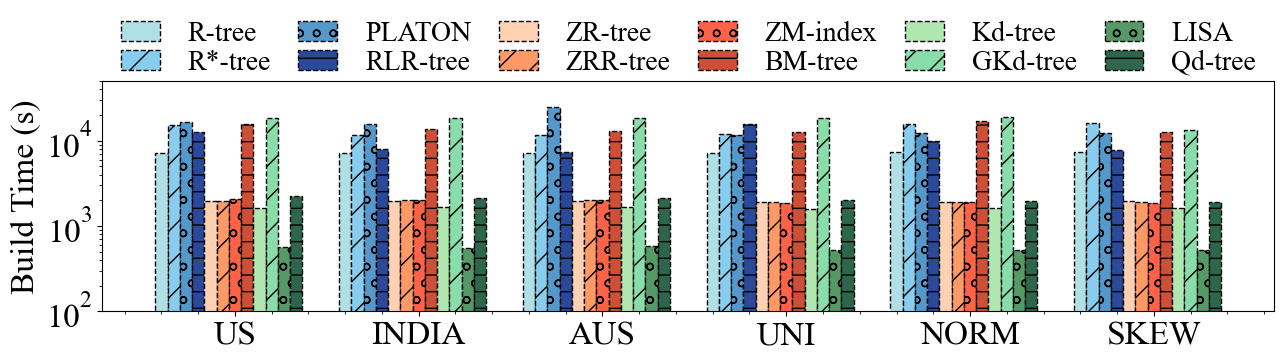

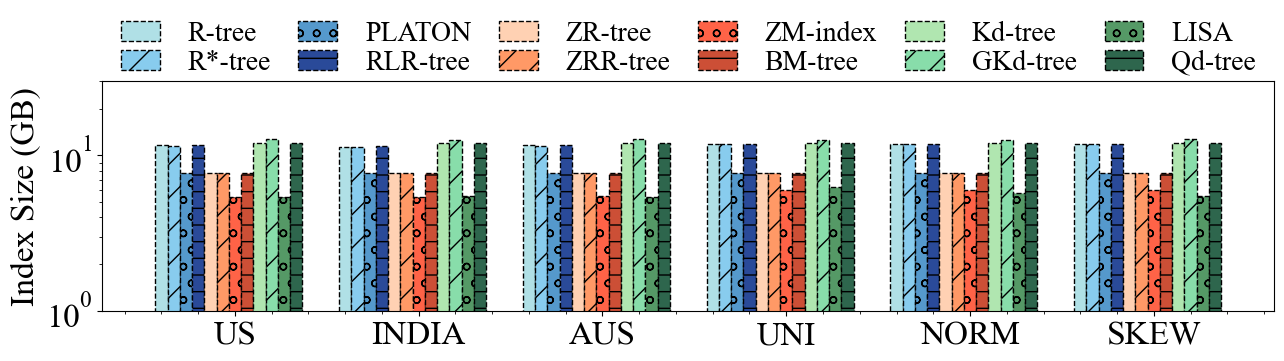

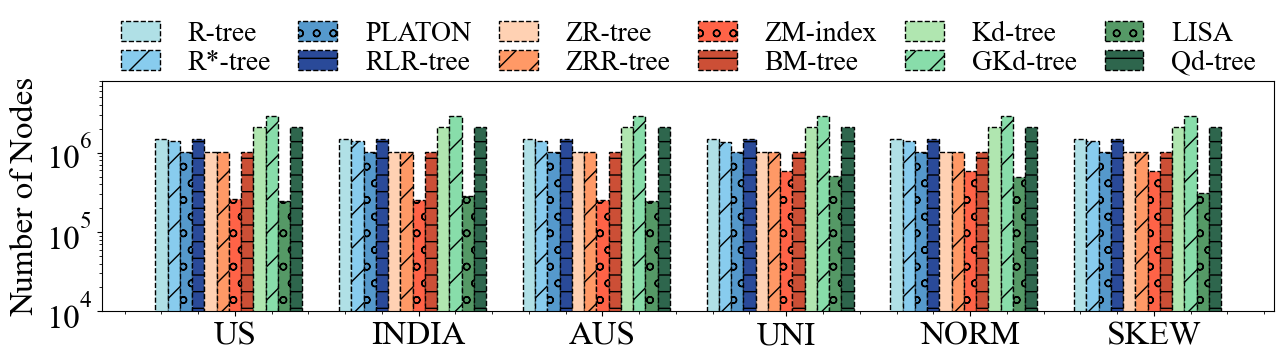

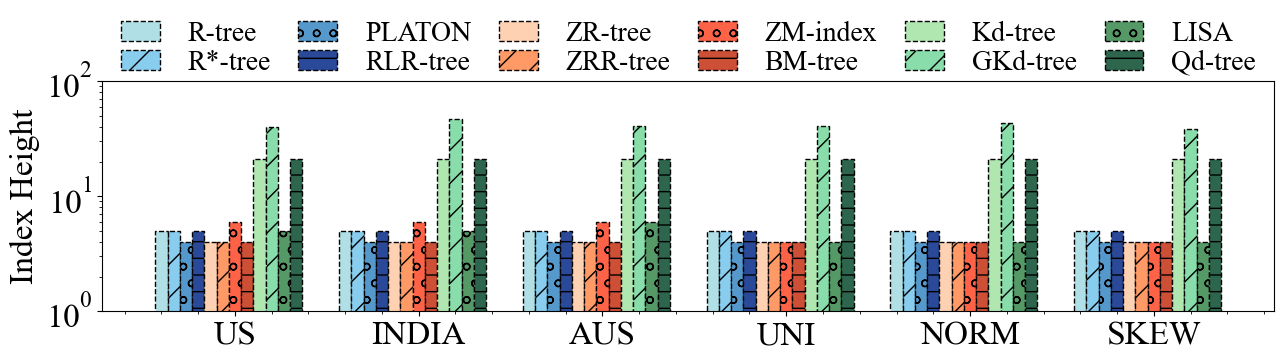

In [4]:
result = []
utilization_result = []
splits_result = []
adjustments_result = []
index_size = []
node_number = []
tree_height = []
build = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_utilization_results = []
    dataset_splits_results = []
    dataset_adjustments_results = []
    dataset_index_size = []
    dataset_node_number = []
    dataset_tree_height = []
    dataset_build = []
    
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            # print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline), build_result_name)
        
        tree_property = parse_rtree_properties(res)
        
        # dataset_results.append({
        #     'ElapsedTime': tree_property.ElapsedTime,
        #     'ElapsedBuildTime': tree_property.ElapsedBuildTime,
        #     'ElapsedLearnTime': tree_property.ElapsedLearnTime
        # })

        dataset_build.append([int(tree_property.ElapsedLearnTime / 1e9 / 60) , int(tree_property.ElapsedBuildTime / 1e9 / 60)])
        # print(tree_property.ElapsedTime, tree_property.ElapsedLearnTime)
        dataset_results.append(float(tree_property.ElapsedTime / 1e9))
        dataset_utilization_results.append(tree_property.Utilization)
        dataset_splits_results.append(tree_property.Splits)
        dataset_adjustments_results.append(tree_property.Adjustments / 1e6)
        dataset_index_size.append((tree_property.TreeDatSize + tree_property.TreeIdxSize) / (1024 * 1024 * 1024))
        dataset_node_number.append(tree_property.NumberOfNodes)
        dataset_tree_height.append(tree_property.TreeHeight)
        # print(baseline, data_name, tree_property.Utilization)
        if baseline == 'platon' or baseline == 'bmtree':
            print(res)

    if baseline == 'platon':
        print(dataset_tree_height)

    result.append(dataset_results) 
    utilization_result.append(dataset_utilization_results) 
    splits_result.append(dataset_splits_results) 
    adjustments_result.append(dataset_adjustments_results) 
    # print(baseline, dataset_adjustments_results)
    index_size.append(dataset_index_size)
    node_number.append(dataset_node_number)
    tree_height.append(dataset_tree_height)
    build.append(dataset_build)

# print(utilization_result)
# print(splits_result)
# print(adjustments_result)
# print(index_size)

print(build[3])
print(build[7])
print(build[10])
# print(tree_height)

plot_hist(display_data_names, display_baselines, result, y_label="Build Time (s)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/build.pdf", "../figs/exp_sigmod/build.png"],bottom=1e2, top=5e4, legend_location="top")

# plot_hist_stack(display_data_names, display_baselines, build, y_label="Build Time (s)",  is_log=True, output_file_paths=
#           [folder + "/figs/build.pdf", "../figs/exp/build.png"], legend_labels=["Build", "Train"])

plot_hist(display_data_names, display_baselines, index_size, y_label="Index Size (GB)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/index_size.pdf", "../figs/exp_sigmod/index_size.png"],bottom=1, top=30, legend_location="top")

plot_hist(display_data_names, display_baselines, node_number, y_label="Number of Nodes", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/node_number.pdf", "../figs/exp_sigmod/node_number.png"],bottom=1e4, top=8e6, legend_location="top")

plot_hist(display_data_names, display_baselines, tree_height, y_label="Index Height", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/tree_height.pdf", "../figs/exp_sigmod/tree_height.png"],bottom=1, top=100, legend_location="top")


#### Point Query

[253.07302223500002, 204.4097162, 316.078666665, 101.930710455, 256.044430995, 274.75888527]
[70.461524125, 66.468538965, 114.199640105, 47.886892875, 77.1494776, 75.303966515]
platon [[2, 3], [2, 4], [2, 4], [2, 4], [2, 4], [2, 4]]
[33.53576615, 33.978677735, 33.276696775, 34.27271331, 36.752828665, 37.037065795000004]
[206.428445845, 177.231031005, 267.91145366499995, 118.676601415, 214.599992825, 227.19959032]
[133.541728845, 126.884098175, 150.76369766500002, 133.89720405, 178.516424565, 274.974612535]
[100.08021472, 98.756115055, 102.469226255, 77.770532235, 329.45290600000004, 380.38968607]
[277.47719153, 267.78732864, 310.25524855000003, 60.325646655, 62.756379005, 64.411581195]
[136.46047451, 158.96685897999998, 156.343508785, 138.34284116999999, 136.39915948, 100.409849555]
[51.254086335, 51.498008070000004, 46.103753235, 53.716509095, 1854.37889698, 3959.3640047149997]
[2110.243643405, 2933.02506868, 2174.035705565, 3013.7562573950004, 2946.53864236, 3793.635574665]
[260.0593

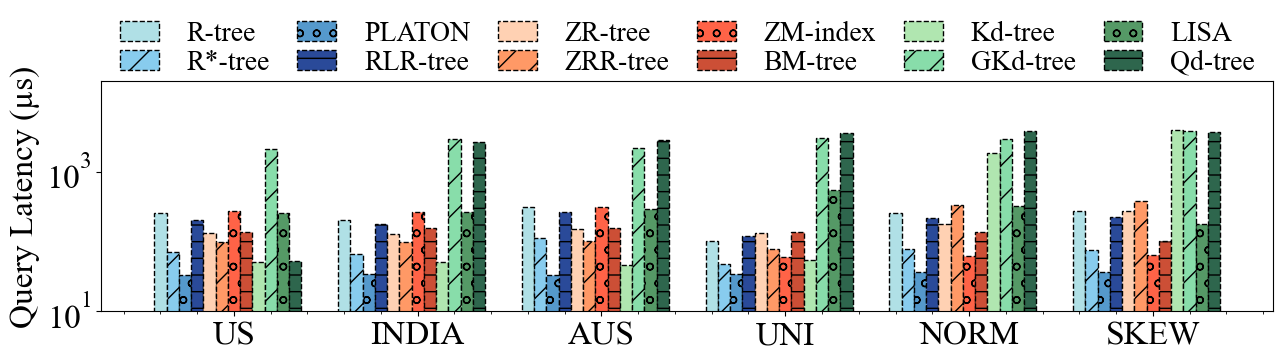

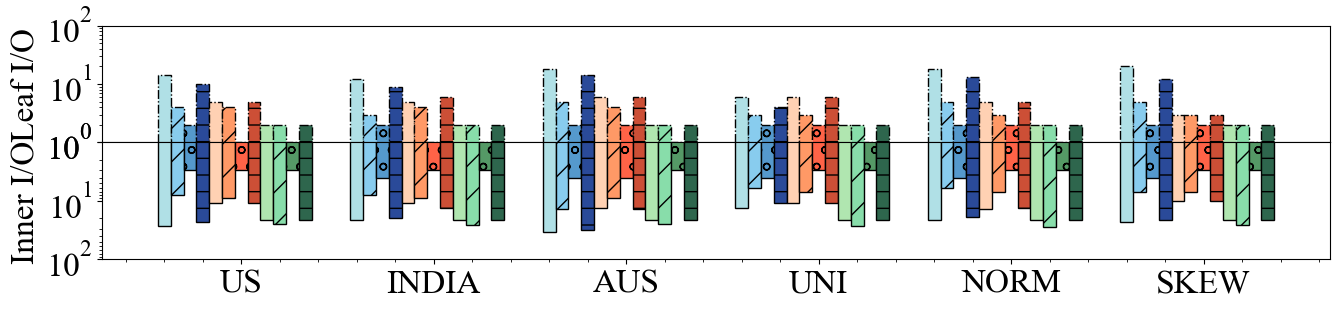

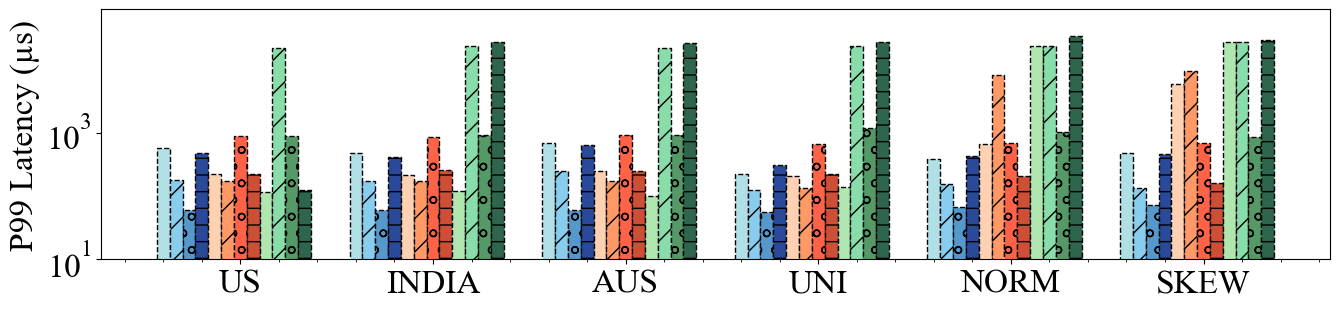

In [5]:
# 1 
# default_range_name = "_{data_name}_range_1000_2_normal_1_0.001x0.001"
real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']

result = []
query_result_num = []
IO = []
P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline), point_result_name)
        
        tree_property = parse_rtree_properties(res)

        # self.QueryNum = kwargs.get('Query num', None)
        # self.QueryMean = kwargs.get('Query mean', None)
        # self.QueryVariance = kwargs.get('Query variance', None)
        # self.QueryStdDev = kwargs.get('Query stdDev', None)
        # self.QueryP50 = kwargs.get('Query p50', None)
        # self.QueryP99 = kwargs.get('Query p99', None)
        

 
        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo) / 200000)
        dataset_IO.append([math.ceil(tree_property.LeafIo / tree_property.QueryNum), math.ceil(tree_property.IndexIo / tree_property.QueryNum)])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
        # if baseline == 'zm':
        #     print(dataset_IO)

        # if baseline == 'rankspace_zorder' or baseline == 'bmtree':
        #     print(baseline + " " + str(float(tree_property.QueryMean / 1000)))
    
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num)
    if baseline == 'platon':
        print("platon", dataset_IO)
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

    print(dataset_results)

# for item in result:
#     print(item)
# print(IO)

# print(query_result_num)
# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", title="Point query result num", output_file_paths=
#           [folder + "/figs/point_result_num.pdf", "../figs/exp/point_result_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query.pdf", "../figs/exp_sigmod/point_query.png"], bottom=1e1, top=2*1e4, legend_location="top")

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/point_IO.pdf", "../figs/exp/point_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O",  is_log=False, output_file_paths=
#           [folder + "/figs/point_IO.pdf", "../figs/exp/point_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
#                 bottom=50, top=70)

# print(display_data_names)
plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_IO.pdf", "../figs/exp_sigmod/point_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], 
                bottom1=1, top1=1e2, bottom2=1, top2=1e2, legend_location="top")

# title="P50 Latency for Point Query"
# plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True,  output_file_paths=
#           [folder + "/exp_sigmod/point_query_P50.pdf", "../figs/exp_sigmod/point_query_P50.png"], bottom=1e1, top=2*1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query_P99.pdf", "../figs/exp_sigmod/point_query_P99.png"], bottom=1e1, top=9*1e4, legend_location="top")

# print(P99)

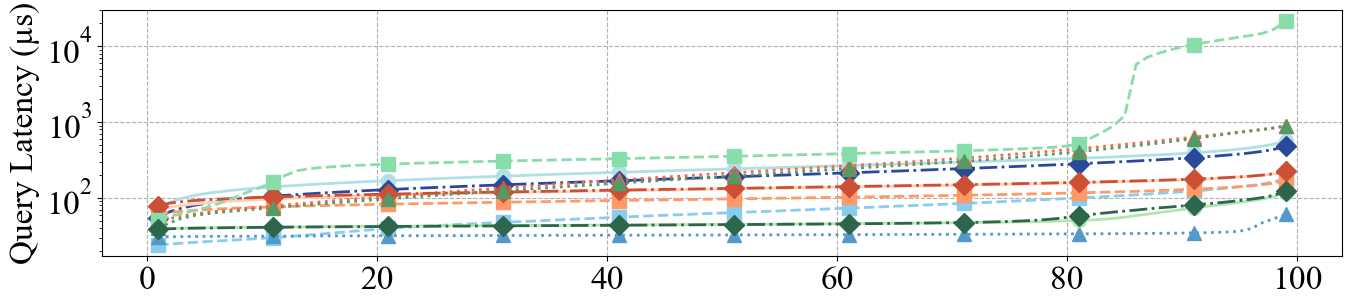

In [6]:
output_file_paths=[folder + "/exp_sigmod/point_query_percentiles.pdf", "../figs/exp_sigmod/point_query_percentiles.png"]

plot_percentail(QueryPercentage, baselines, display_baselines, xlabel="", ylabel="Query Latency (µs)", is_log=True, is_legend=False, output_file_paths=output_file_paths)


#### Range Query

[5947.274451, 2532.6837969999997, 17215.211517, 364.46353999999997, 355.336663, 284.41680699999995]
[4897.0567089999995, 1863.649081, 15001.145514, 104.77865700000001, 99.63717600000001, 84.628354]
platon [[145.975, 4.731], [64.529, 3.693], [584.706, 9.737], [2.009, 3.006], [1.956, 3.004], [2.077, 3.002]]
platon [24975.709, 14611.769, 85039.762, 106.017, 172.13, 667.877]
[3713.208331, 1671.09845, 13618.224424, 61.342542, 59.885375999999994, 59.026968999999994]
[9446.884125, 3295.546898, 21870.280465999997, 565.713893, 332.960081, 819.133465]
[4021.6963229999997, 1661.198386, 11547.032484, 255.169813, 10971.839356, 152.017608]
rankspace_zorder [[176.098, 12.737], [83.728, 10.343], [633.261, 20.086], [7.349, 7.195], [7.064, 6.127], [7.266, 5.441]]
[4173.780533, 1630.370435, 11491.453752, 145.871439, 2255.0637110000002, 146.5778]
[3305.975062, 2022.162794, 5544.953308, 135.149421, 176.74819399999998, 215.658298]
[4155.363062, 1948.486086, 13671.837911, 211.430172, 186.727899, 159.371631]


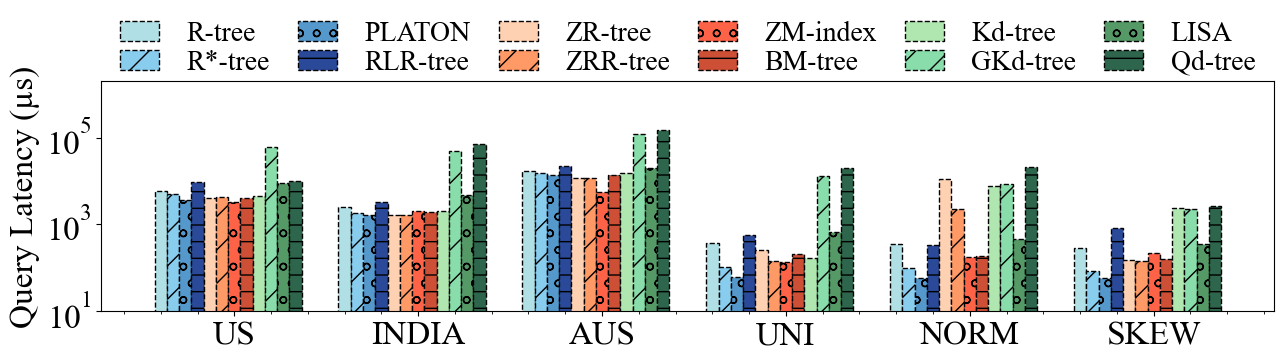

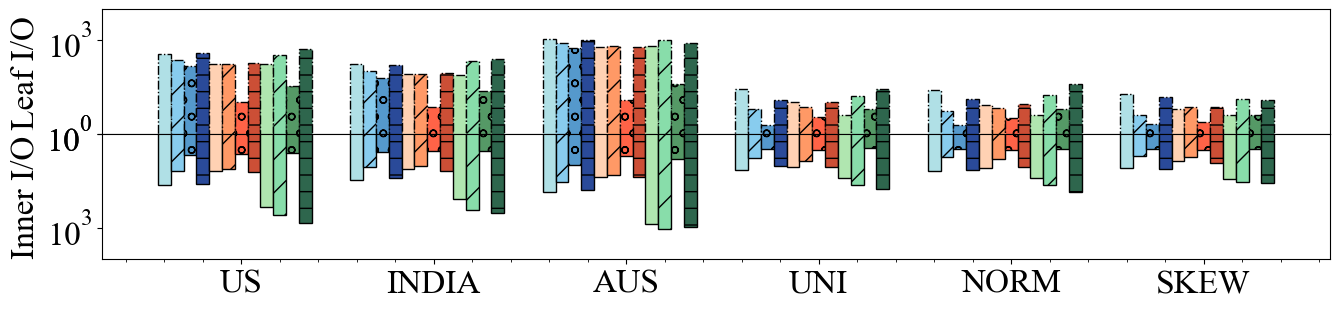

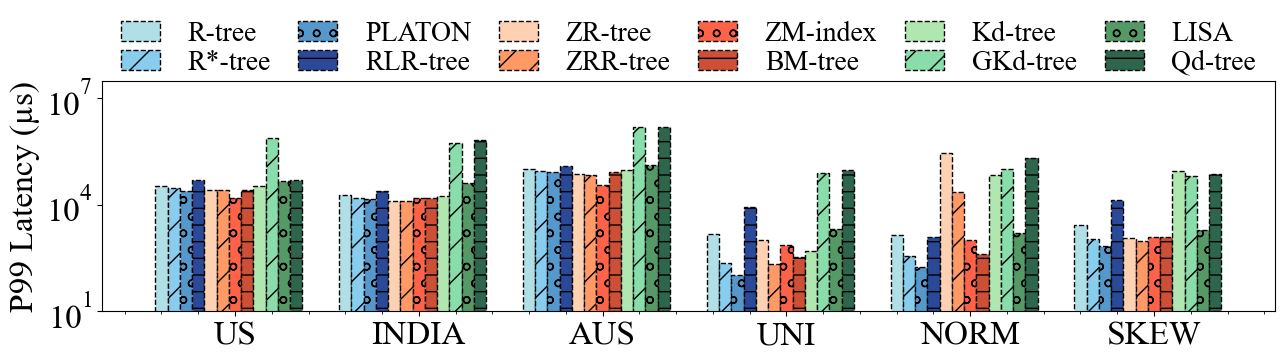

[[4155.363062, 4155.363352],
 [1948.486086, 1948.48696],
 [13671.837911, 13758.155001000001],
 [332.76193199999994, 249.264573],
 [263.433365, 186.893579],
 [159.371631, 143.44544699999997]]

In [7]:
real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"
result = []
IO = []

P99 = []
P50 = []

query_result_num = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            # print(suffix)
            
        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern
        else:
            range_name=real_range_name_pattern.format(data_name=data_name)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)

        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo)/1000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
    if baseline == 'platon':
        print("platon", dataset_IO)
        print("platon", dataset_P99)
    if baseline == 'rankspace_zorder':
        print("rankspace_zorder", dataset_IO) 
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num) 
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

    print(dataset_results)

# # print(IO)
# for item in result:
#     print(item)


# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/range_query_result_num.pdf", "../figs/exp/range_query_result_num.png"])

# plot_hist(data_names, baselines, result)
plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time.pdf", "../figs/exp_sigmod/range_query_time.png"], bottom=1e1, top=2*1e6, legend_location="top")

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], legend_location="right")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO.pdf", "../figs/exp_sigmod/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],
                bottom1=1, top1=10000, bottom2=1, top2=10000, legend_location="top")

# plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/exp_sigmod/range_query_P50.pdf", "../figs/exp_sigmod/range_query_P50.png"], bottom=1e1, top=2*1e6)

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99.pdf", "../figs/exp_sigmod/range_query_P99.png"], bottom=1e1, top=3*1e7, legend_location="top")


[[4155.363062, 4155.363352], [1948.486086, 1948.48696], [13671.837911, 13758.155001000001], [332.76193199999994, 249.264573], [263.433365, 186.893579], [159.371631, 143.44544699999997]]

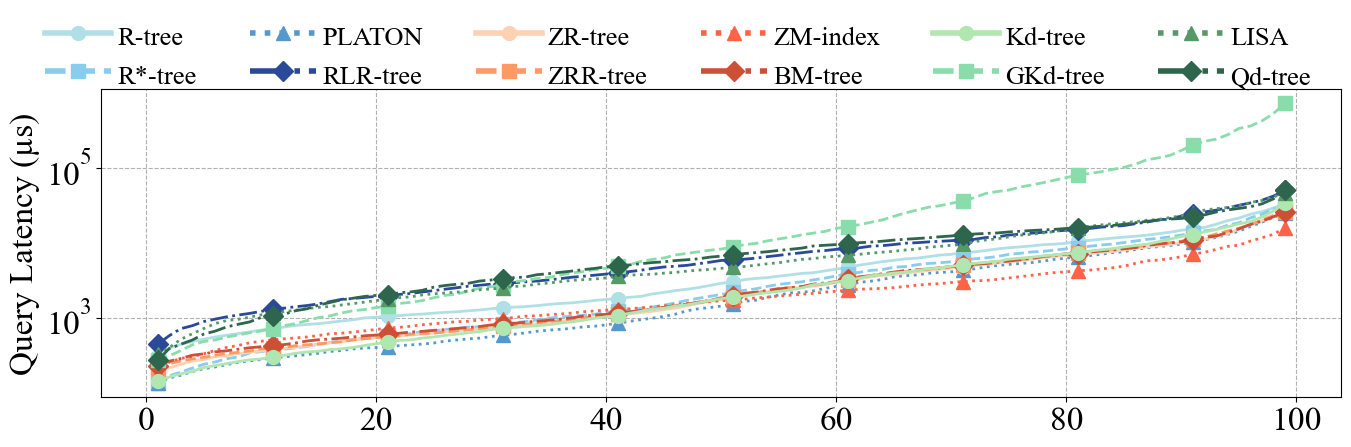

In [8]:
output_file_paths=[folder + "/exp_sigmod/range_query_percentiles.pdf", "../figs/exp_sigmod/range_query_percentiles.png"]

plot_percentail(QueryPercentage, baselines, display_baselines, xlabel="", ylabel="Query Latency (µs)", is_log=True, is_legend=True, output_file_paths=output_file_paths)


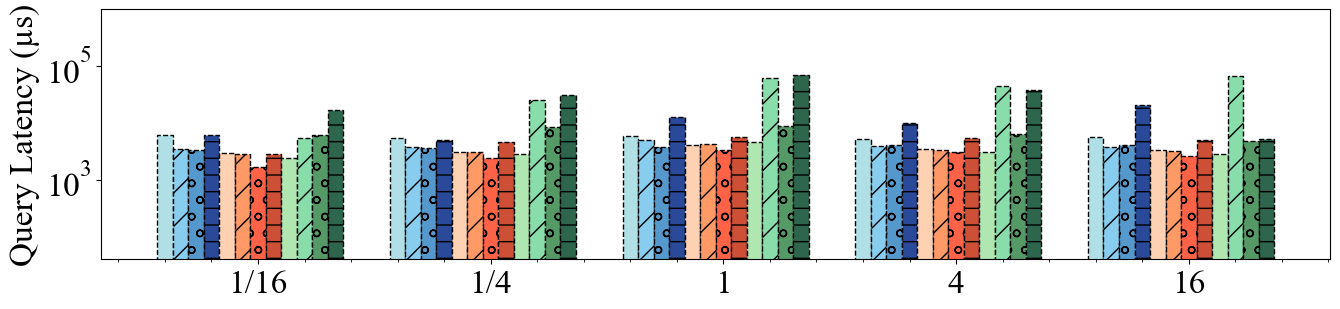

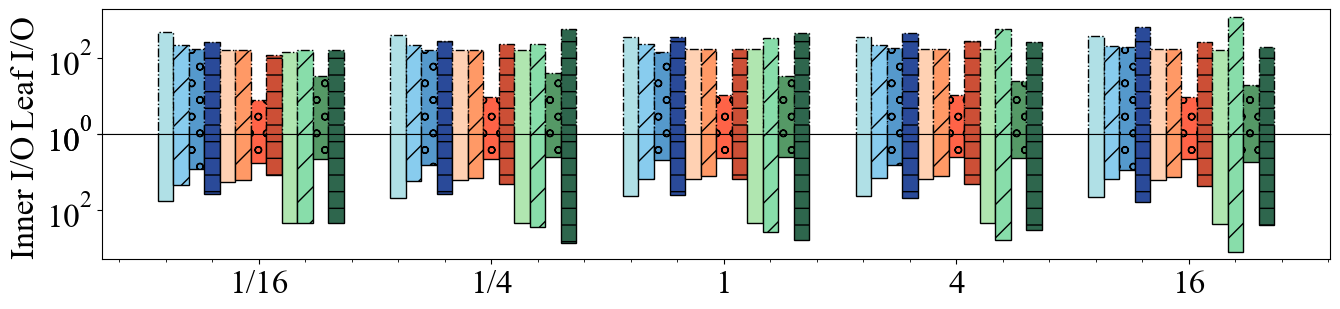

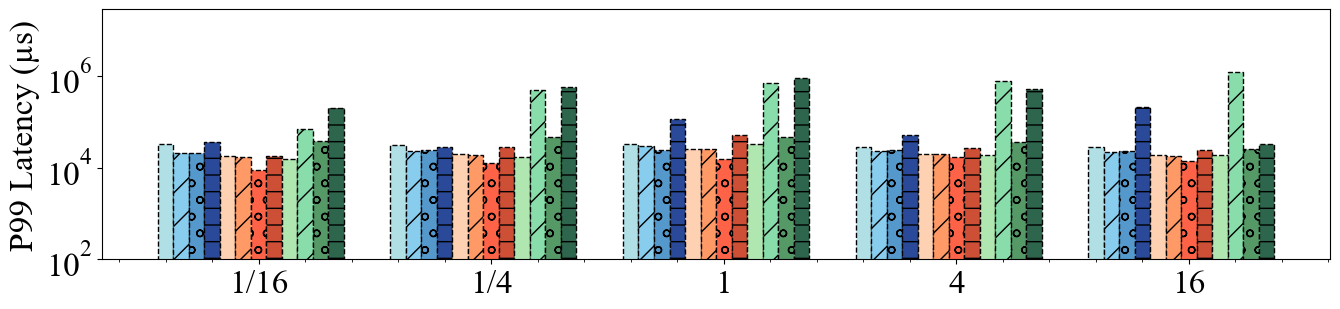

In [9]:
# 1 
data_name = "us_100000000"
dis_data_name = "US"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

query_range_r1 = [0.00025, 0.0005, 0.001, 0.002, 0.004]
query_range_r2 = [0.004, 0.002, 0.001, 0.0005, 0.00025]

# display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]
display_query_ranges = ["1/16", "1/4", "1", "4", "16"]

baseline_suffix = {'bmtree':'_bits_32_depth_12_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    # if baseline in output_dict[dis_data_name].keys():
    #     suffix = output_dict[dis_data_name][baseline]
    #     print(suffix)
        
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for i in range(len(query_range_r1)):
        r1 = query_range_r1[i]
        r2 = query_range_r2[i]
        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern.format(r1=r1,r2=r2)
        else:
            range_name=real_range_name_pattern.format(data_name=data_name,r1=r1,r2=r2)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)

# print(IO)
# print(result)

# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_query_ranges, display_baselines, result, y_label="Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_time_varying_aspect_ratio.png"], bottom=4*1e1, top=1*1e6, legend_location="top")

# plot_hist_stack(display_query_ranges, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO_varying_range.pdf", "../figs/exp/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=1, top=5*1e4)

plot_hist_stack_mirrored(display_query_ranges, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_IO_varying_aspect_ratio.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1e3, bottom2=1, top2=2*1e3)

# plot_hist(display_query_ranges, display_baselines, P50, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/exp_sigmod/range_query_P50_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_P50_varying_aspect_ratio.png"], bottom=4*1e1, top=1*1e6)

plot_hist(display_query_ranges, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_varying_aspect_ratio.pdf", "../figs/exp_sigmod/range_query_P99_varying_aspect_ratio.png"], bottom=1e2, top=3*1e7)

250483.538
1523249.977
5581144.488
43188285.994
109000681.982


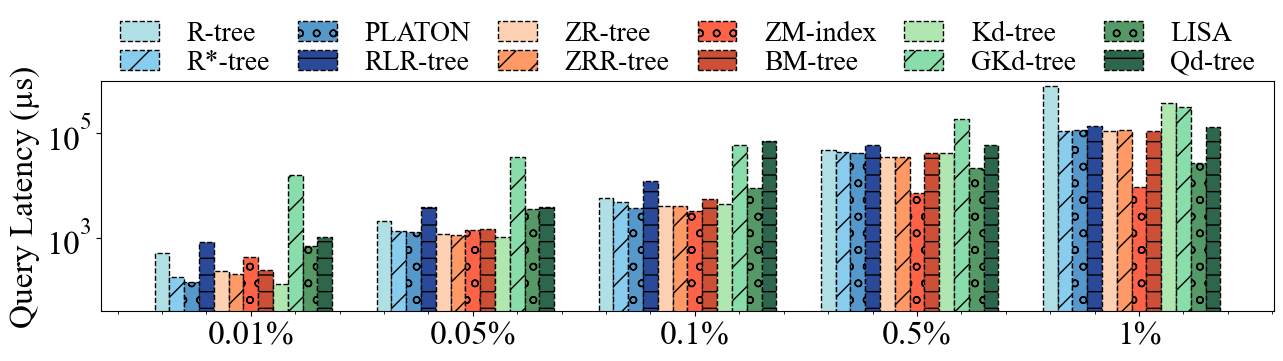

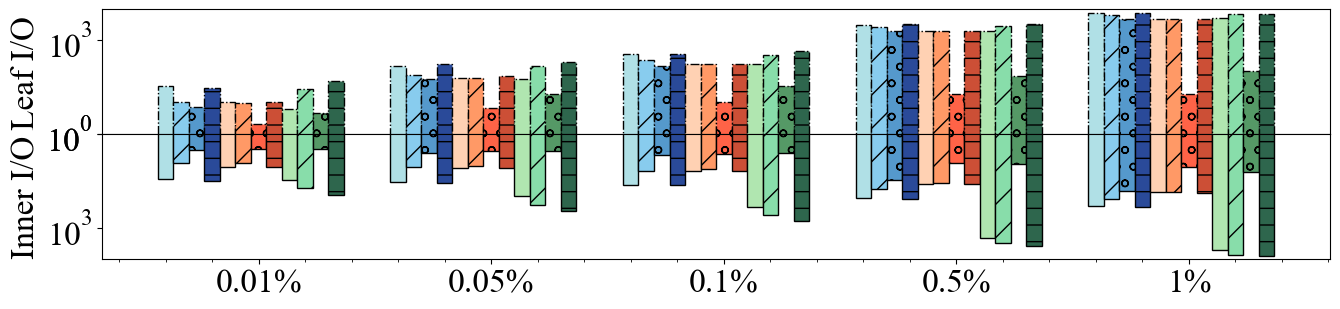

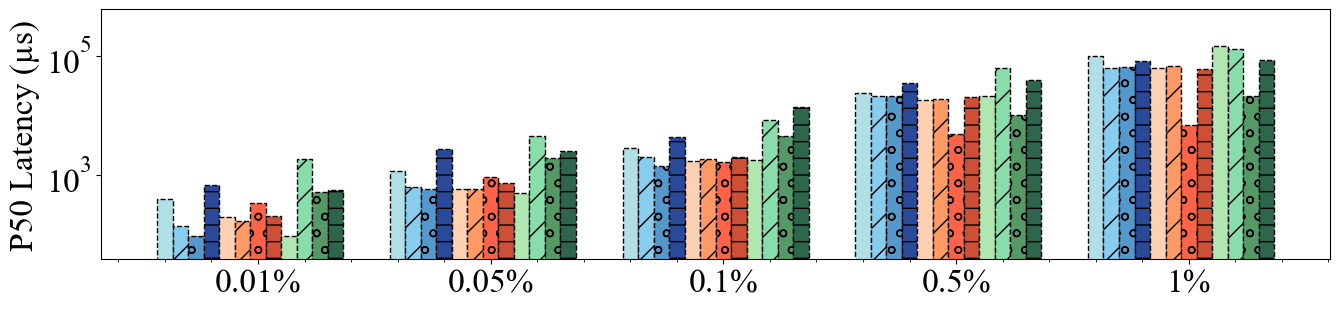

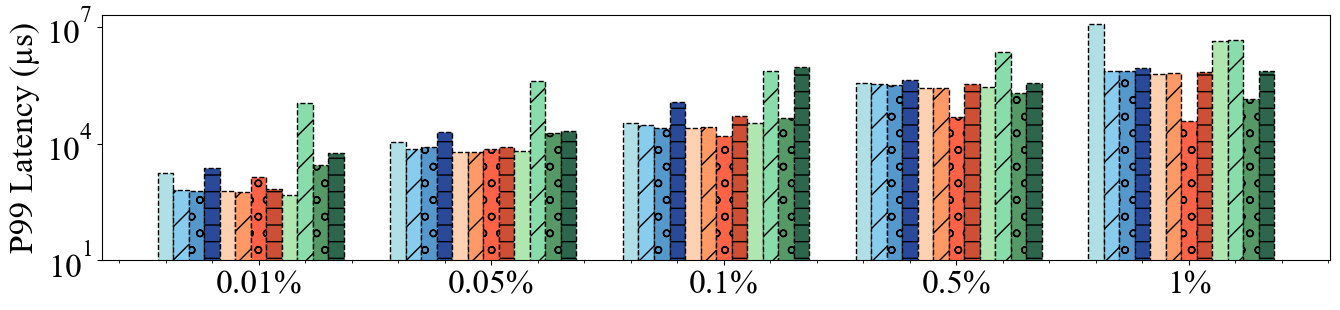

In [10]:
# 1 
data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for query_range in query_ranges:

        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern.format(r1=query_range,r2=query_range)
        else:
            range_name=real_range_name_pattern.format(data_name=data_name,r1=query_range,r2=query_range)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)

        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)

        if baseline == 'bmtree':
            # print(res)
            print(tree_property.QueryMean)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    
# print(IO)
# print(result)


# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_query_ranges, display_baselines, result, y_label="Query Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_varying_range.pdf", "../figs/exp_sigmod/range_query_time_varying_range.png"], bottom=4*1e1, top=1e6, legend_location="top")

# plot_hist_stack(display_query_ranges, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO_varying_range.pdf", "../figs/exp/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=1, top=5*1e4)

plot_hist_stack_mirrored(display_query_ranges, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_varying_range.pdf", "../figs/exp_sigmod/range_query_IO_varying_range.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=10000, bottom2=1, top2=10000)

plot_hist(display_query_ranges, display_baselines, P50, y_label="P50 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P50_varying_range.pdf", "../figs/exp_sigmod/range_query_P50_varying_range.png"], bottom=4*1e1, top=6*1e5)

plot_hist(display_query_ranges, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_varying_range.pdf", "../figs/exp_sigmod/range_query_P99_varying_range.png"], bottom=1e1, top=2*1e7)

#### knn Query

_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_40000
_rlrtree_epoch_8_sample_40000
_bits_32_depth_12_sample_40000
_bits_32_depth_12_sample_40000
_bits_32_depth_12_sample_40000
_bits_32_depth_12_sample_40000
_bits_32_depth_12_sample_40000
_bits_32_depth_12_sample_40000
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0008_action_space_200
_episode_10_sampling_ratio_0.0008_action_space_200


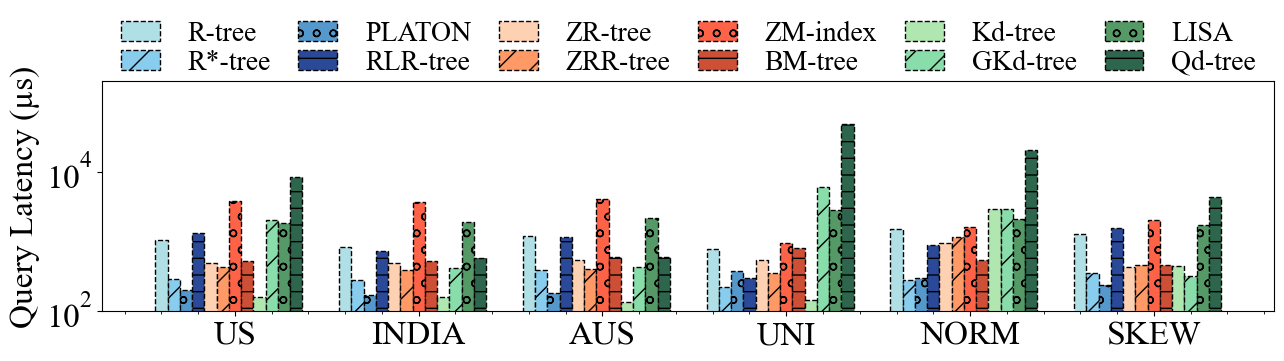

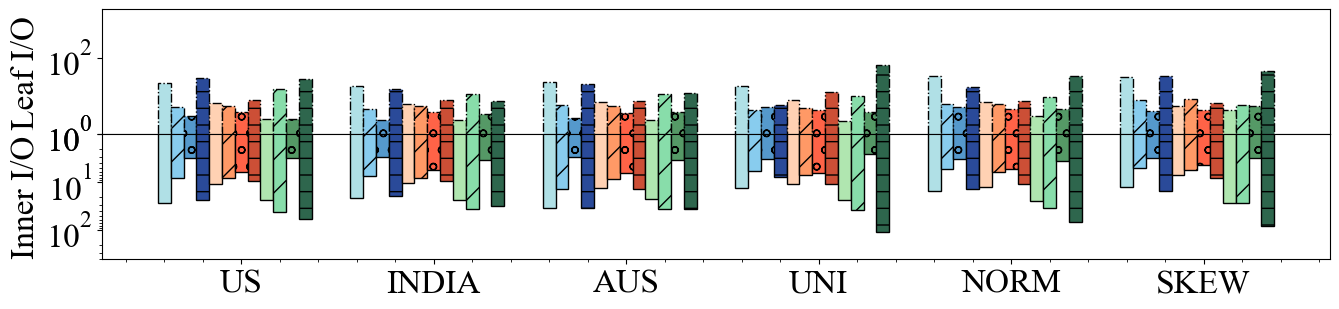

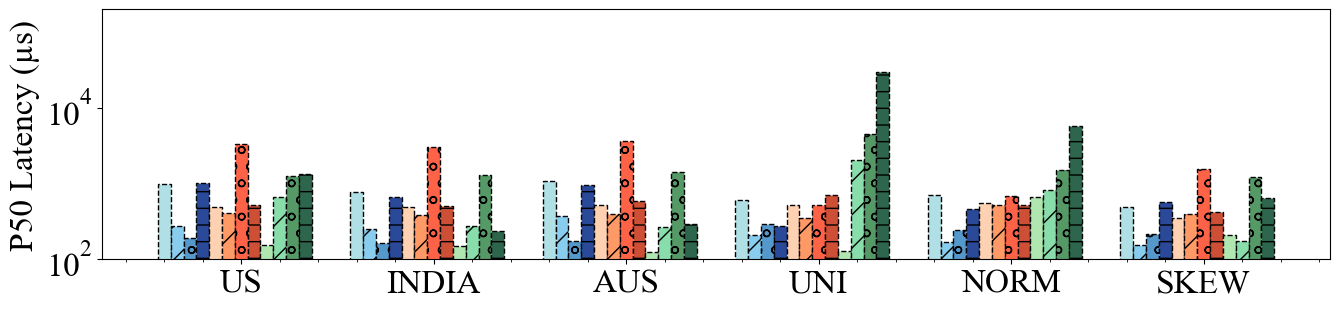

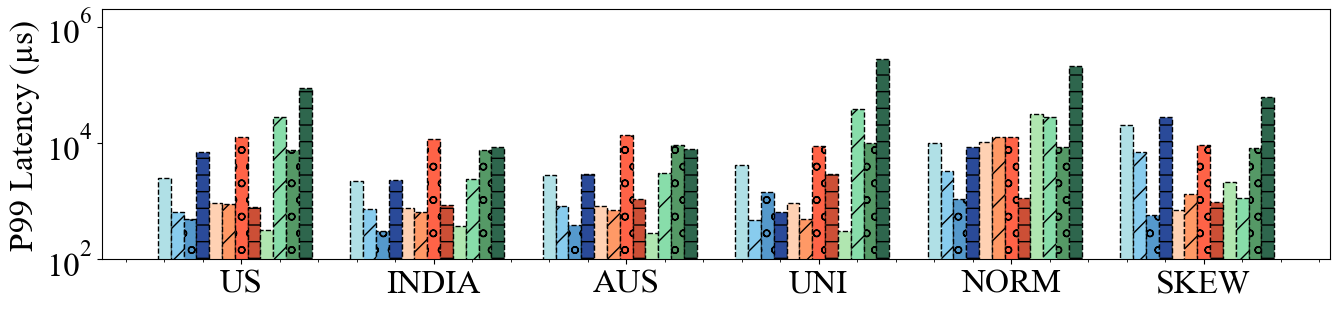

In [11]:
# 1 
data_name = "us_100000000"
k=25
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']

result = []
result_num = []
IO = []

P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for data_name in data_names:

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # print(tree_property.QueryNum, data_name, baseline)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage
    
# for item in result:
#     print(item)

# print(IO)
# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time.pdf", "../figs/exp_sigmod/knn_query_time.png"], bottom=1e2, top=2*1e5, legend_location="top")

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=False, output_file_paths=
#           [folder + "/figs/knn_query_IO.pdf", "../figs/exp/knn_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], bottom=0, top=150)

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO.pdf", "../figs/exp_sigmod/knn_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1000, bottom2=1, top2=400)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50.pdf", "../figs/exp_sigmod/knn_query_P50.png"], bottom=1e2, top=2*1e5)

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99.pdf", "../figs/exp_sigmod/knn_query_P99.png"], bottom=1e2, top=2*1e6)

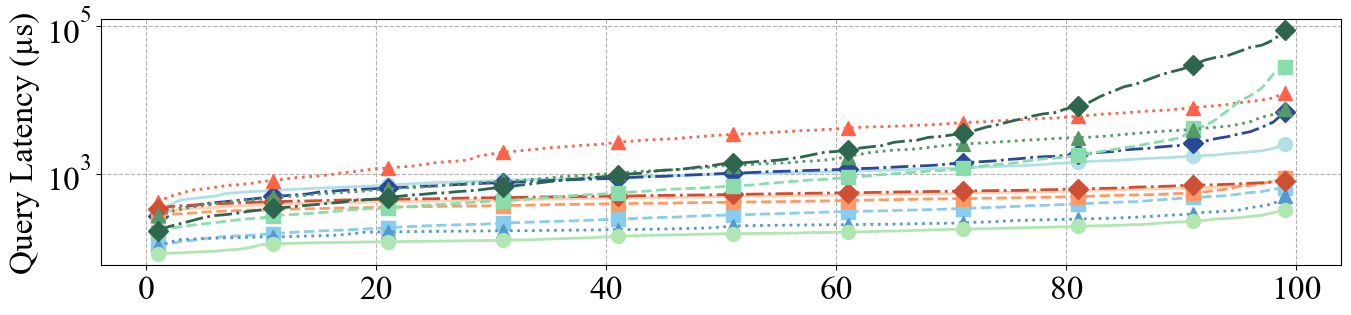

In [12]:
output_file_paths=[folder + "/exp_sigmod/knn_query_percentiles.pdf", "../figs/exp_sigmod/knn_query_percentiles.png"]

plot_percentail(QueryPercentage, baselines, display_baselines, xlabel="", ylabel="Query Latency (µs)", is_log=True, is_legend=False, output_file_paths=output_file_paths)


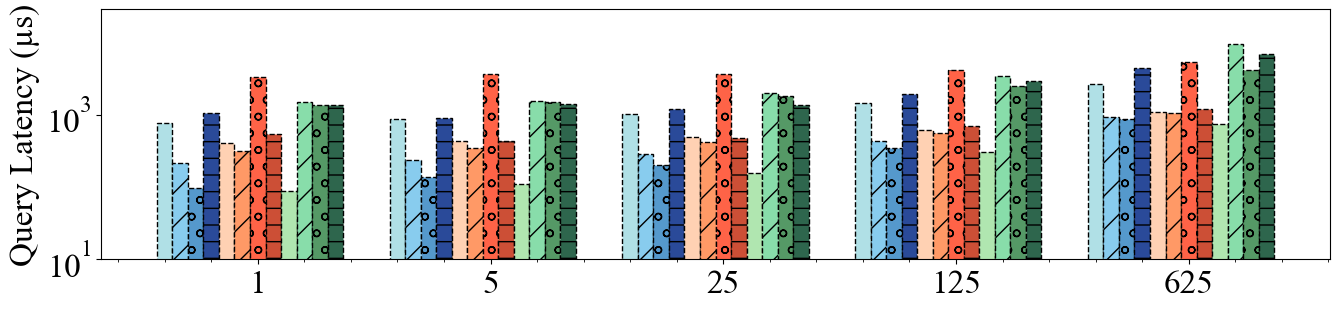

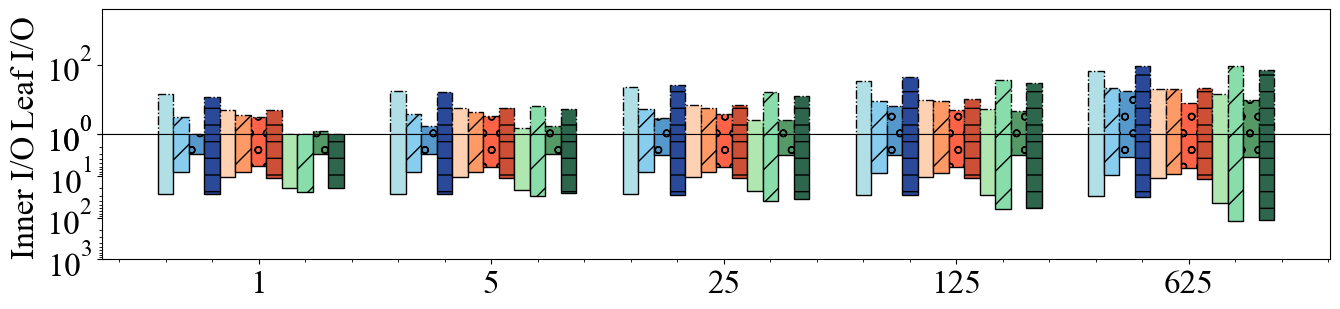

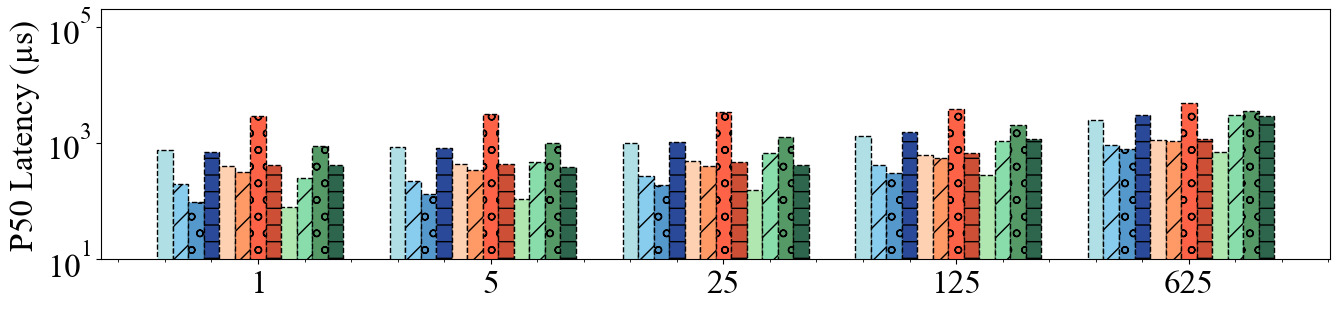

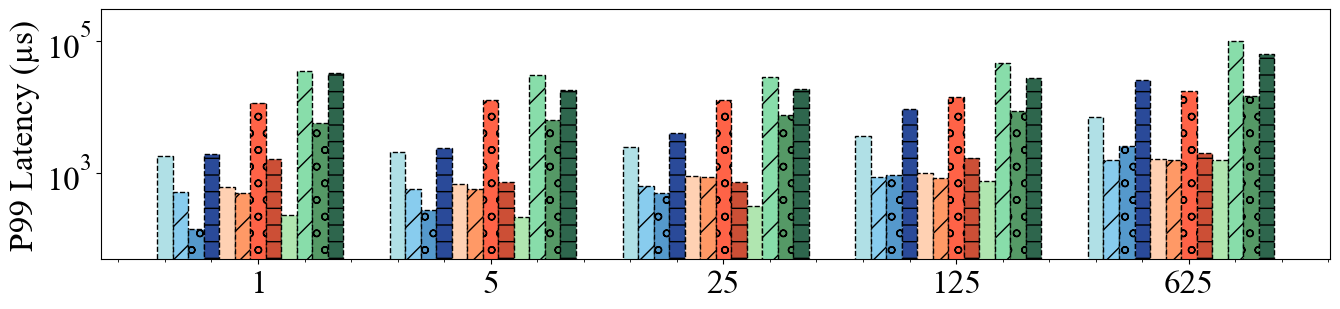

In [13]:
# 1 
data_name = "us_100000000"
ks=[1, 5, 25, 125, 625]
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree','platon']

display_ks = [str(k) for k in ks]

result = []
result_num = []
IO = []

P99 = []
P50 = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    for k in ks:

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)


# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_ks, display_baselines, result, y_label="Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time_varying_k.pdf", "../figs/exp_sigmod/knn_query_time_varying_k.png"], bottom=1e1, top=3*1e4)

# plot_line(display_ks, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/knn_query_IO_varying_k.pdf", "../figs/exp/knn_query_IO_varying_k.png"])

# plot_hist_stack(display_ks, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/knn_query_IO_varying_k.pdf", "../figs/exp/knn_query_IO_varying_k.png"], legend_labels=["Leaf I/O", "Inner I/O"]
#                , bottom=0.9)

plot_hist_stack_mirrored(display_ks, display_baselines, IO, y_label="I/O",  is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO_varying_k.pdf", "../figs/exp_sigmod/knn_query_IO_varying_k.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=4*1000, bottom2=1, top2=1000)

plot_hist(display_ks, display_baselines, P50, y_label="P50 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50_varying_k.pdf", "../figs/exp_sigmod/knn_query_P50_varying_k.png"], bottom=1e1, top=2*1e5)

plot_hist(display_ks, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99_varying_k.pdf", "../figs/exp_sigmod/knn_query_P99_varying_k.png"], bottom=5*1e1, top=3*1e5)

['25%', '50%', '75%', '100%']
_quadratic
_rstar

_rlrtree_epoch_8_sample_80000
_bits_32
_bits_32
_bits_32
_bits_32_depth_12_sample_10000



_episode_10_sampling_ratio_0.0001_action_space_400
point path: ../result/libspatialindex/HDD/4K/qdtree/point/us_25000000_us_25000000_range_1000_2_uniform_1_0.001x0.001_us_25000000_point_200000_2_uniform_1_episode_10_sampling_ratio_0.0001_action_space_400.txt
point path: ../result/libspatialindex/HDD/4K/qdtree/point/us_50000000_us_50000000_range_1000_2_uniform_1_0.001x0.001_us_50000000_point_200000_2_uniform_1_episode_10_sampling_ratio_0.0001_action_space_400.txt
point path: ../result/libspatialindex/HDD/4K/qdtree/point/us_75000000_us_75000000_range_1000_2_uniform_1_0.001x0.001_us_75000000_point_200000_2_uniform_1_episode_10_sampling_ratio_0.0001_action_space_400.txt
point path: ../result/libspatialindex/HDD/4K/qdtree/point/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_us_100000000_point_200000_2_uniform_1_episode_10_sampling_ratio_0.

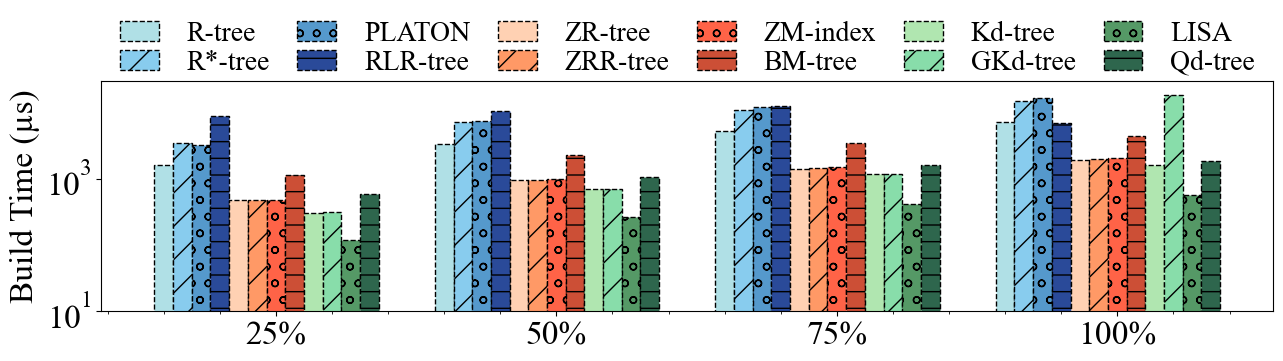

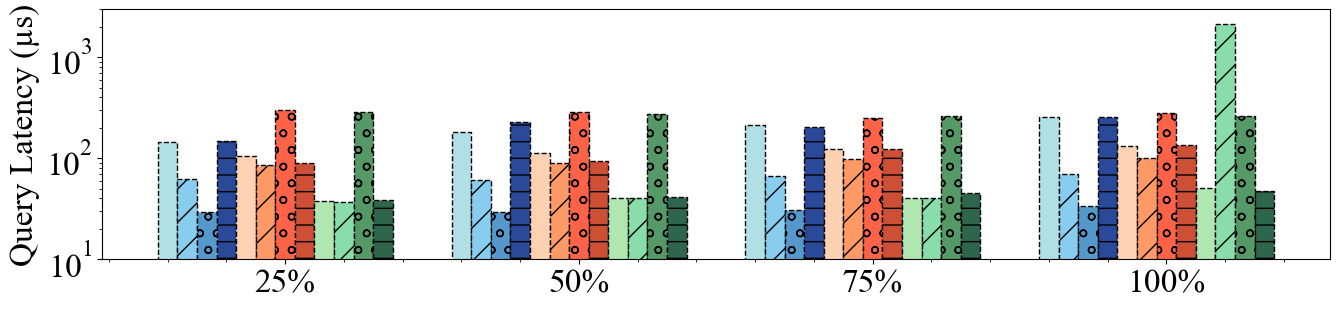

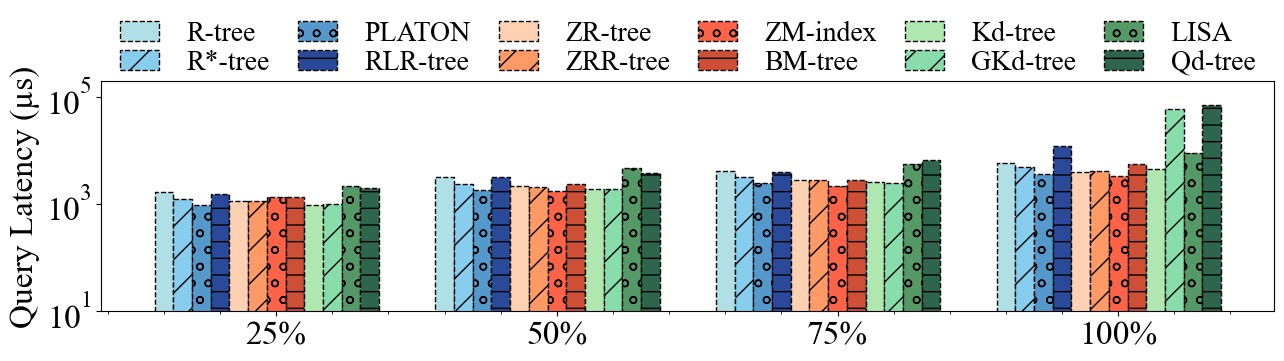

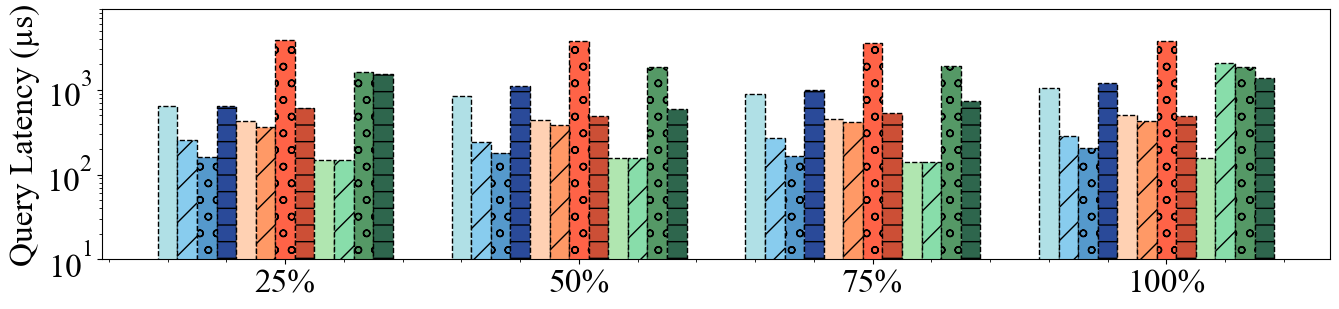

In [14]:
# 1 
data_name_pattern = "us_{cardinality}"

cardinalities = [25000000, 50000000, 75000000, 100000000]
query_range = 0.001
k = 25
ks=[1, 5, 25, 125, 625]
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree','platon']

display_ks = [str(k) for k in ks]

display_cardinality = [str(k // 1000000) + "%" for k in cardinalities]

print(display_cardinality)

point_query = []
range_query = []
knn_query = []
point_query_IO = []
range_query_IO = []
knn_query_IO = []
build_time = []


for baseline in baselines:


    suffix = baseline_suffix[baseline]
    print(suffix)
    point_query_dataset = []
    range_query_dataset = []
    knn_query_dataset = []
    point_query_IO_dataset = []
    range_query_IO_dataset = []
    knn_query_IO_dataset = []
    build_time_dataset = []

    for cardinality in cardinalities:
        
        # if cardinality == 100000000 and baseline in output_dict[display_data_names[i]].keys():
        #     suffix = output_dict[display_data_names[i]][baseline]
        # else:
        if baseline not in baseline_suffix.keys():
            continue
            suffix = baseline_suffix[baseline]
        


        # if data_name.startswith("data"):
        #     range_name = synthetic_range_name_pattern.format(r1=query_range,r2=query_range)
        #     point_name = synthetic_point_name.format(data_name=data_name)
        #     knn_name = synthetic_knn_name
        #     default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        # else:
        range_name=real_range_name_pattern.format(data_name=data_name_pattern.format(cardinality=cardinality),r1=query_range,r2=query_range)
        point_name = real_point_name.format(data_name=data_name_pattern.format(cardinality=cardinality))
        knn_name = real_knn_name.format(data_name=data_name_pattern.format(cardinality=cardinality))
        default_range_name=real_default_range_name_pattern.format(data_name=data_name_pattern.format(cardinality=cardinality)) if baseline in special_baselines else ''

        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name_pattern.format(cardinality=cardinality),
            default_range_name=default_range_name,
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline), build_result_name)
        # print(res)
        tree_property = parse_rtree_properties(res)
        build_time_dataset.append(tree_property.ElapsedTime / 1e9)

        
        # build_time_sampled.append((tree_property.ElapsedBuildTime + tree_property.ElapsedLearnTime) / 1e9)

        point_result_name = point_result_name_pattern.format(
            data_name=data_name_pattern.format(cardinality=cardinality),
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        
        res = os.path.join(point_result_path.format(name=baseline), point_result_name)
        tree_property = parse_rtree_properties(res)
        if baseline == "qdtree":
            print("point path:", res)
        point_query_IO_dataset.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
        point_query_dataset.append(tree_property.QueryMean / 1e3)        
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name_pattern.format(cardinality=cardinality),
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)
        tree_property = parse_rtree_properties(res)
        range_query_IO_dataset.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
        range_query_dataset.append(tree_property.QueryMean / 1e3)


        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name_pattern.format(cardinality=cardinality),
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_IO_dataset.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
        knn_query_dataset.append(tree_property.QueryMean / 1e3)
        
    point_query_IO.append(point_query_IO_dataset)
    range_query_IO.append(range_query_IO_dataset)
    knn_query_IO.append(knn_query_IO_dataset)
    point_query.append(point_query_dataset)
    range_query.append(range_query_dataset)
    knn_query.append(knn_query_dataset)
    build_time.append(build_time_dataset)

plot_hist(display_cardinality, display_baselines, build_time, y_label="Build Time (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/build_time_varying_cardinality.pdf", "../figs/exp_sigmod/build_time_varying_cardinality.png"], bottom=1e1, top=3*1e4, legend_location="top")

plot_hist(display_cardinality, display_baselines, point_query, y_label="Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query_time_varying_cardinality.pdf", "../figs/exp_sigmod/point_query_time_varying_cardinality.png"], bottom=1e1, top=3*1e3, legend_location="top")

plot_hist(display_cardinality, display_baselines, range_query, y_label="Query Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_varying_cardinality.pdf", "../figs/exp_sigmod/range_query_time_varying_cardinality.png"], bottom=1e1, top=2*1e5, legend_location="top")

plot_hist(display_cardinality, display_baselines, knn_query, y_label="Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time_varying_cardinality.pdf", "../figs/exp_sigmod/knn_query_time_varying_cardinality.png"], bottom=1e1, top=9*1e3, legend_location="top")